--- Starting Income vs. Consumption Analysis (English, PDF output) ---
Loaded 103 sector mappings from: ..\resultados\de_para_setores_consumidores.csv
Total consumers in Itapuã: 19,630


Sectors with valid consumption data: 103


Final Sectors for Analysis: 99


PDF plot saved to: ..\figuras\grafico_resultado_analise_consumo_x_renda_itapua_en.pdf


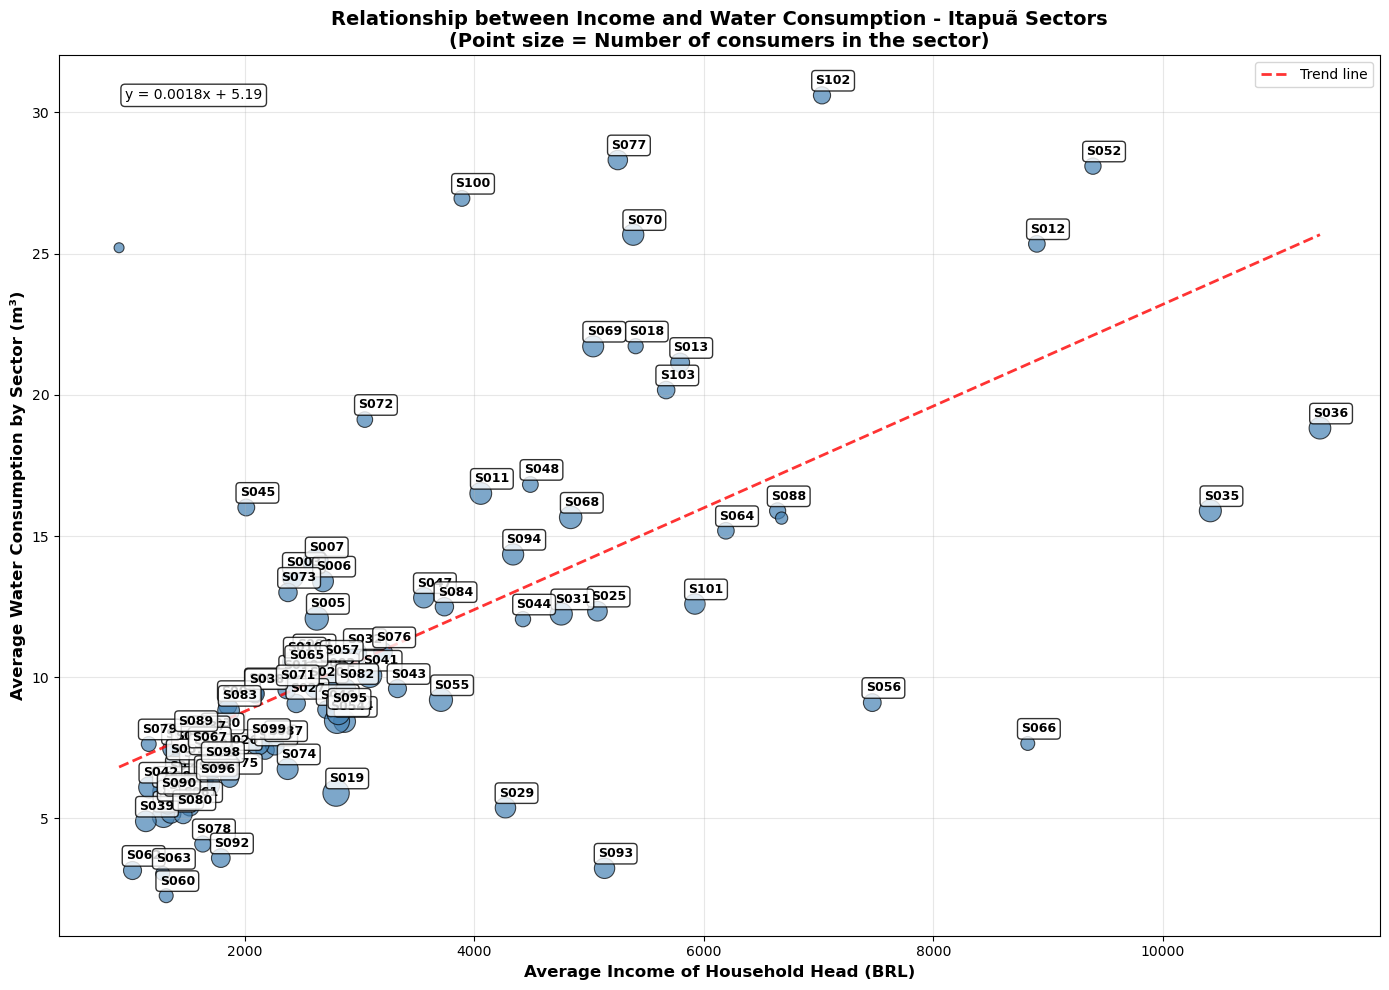


STATISTICAL ANALYSIS - INCOME vs CONSUMPTION
Mean Income: R$ 3187.53
Median Income: R$ 2439.49
Std Dev Income: R$ 2191.23

Mean Consumption: 10.93 m³
Median Consumption: 9.10 m³
Std Dev Consumption: 6.23 m³

Pearson Correlation: 0.634
Interpretation: Moderate positive correlation

TOP 10 SECTORS BY CONSUMPTION
Sector  Avg Cons (m³)  Avg Income (R$)  Consumers
  S102      30.604557          7029.33        128
  S077      28.314208          5250.28        183
  S052      28.097727          9390.18        110
  S100      26.955000          3892.08        100
  S070      25.670790          5384.51        231
  S012      25.345506          8901.60        117
  S097      25.208333           904.80          2
  S018      21.723180          5405.89         87
  S069      21.716642          5035.70        224
  S013      21.142294          5793.16        169

BOTTOM 10 SECTORS BY CONSUMPTION
Sector  Avg Cons (m³)  Avg Income (R$)  Consumers
  S060       2.265625          1315.40         64
  S

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# 1. Configuration and Style
# ==========================================
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Base Paths
BASE_PATH = '..'

# Behavior Classification Thresholds
THRESHOLD_ENVIRONMENTALIST = 100.0
THRESHOLD_WASTEFUL = 121.5

def load_sector_mapping(mapping_path):
    """
    Loads the DE-PARA sector mapping file generated by the main script.
    Returns a dictionary for converting original sector IDs to simplified IDs.
    """
    if not os.path.exists(mapping_path):
        print(f"Warning: Mapping file not found: {mapping_path}")
        print("Will use fallback conversion method.")
        return None
    
    mapping_df = pd.read_csv(mapping_path, sep=';', encoding='utf-8-sig')
    
    # Create mapping dictionary: original -> simplified
    sector_mapping = dict(zip(
        mapping_df['SETOR_ORIGINAL'].astype(str),
        mapping_df['SETOR_SIMPLIFICADO']
    ))
    
    print(f"Loaded {len(sector_mapping)} sector mappings from: {mapping_path}")
    return sector_mapping

def convert_sector_id_with_mapping(full_sector_id, sector_mapping):
    """
    Converts sector ID using the mapping file.
    If mapping not available, falls back to short conversion.
    """
    sector_str = str(full_sector_id)
    
    # Try to use mapping first
    if sector_mapping and sector_str in sector_mapping:
        return sector_mapping[sector_str]
    
    # Fallback: convert to short format SXXX
    if len(sector_str) >= 9:
        return 'S' + sector_str[7] + sector_str[-2:]
    else:
        return f'S{hash(sector_str) % 1000:03d}'

def clean_income_value(value):
    """
    Converts income string values to float, handling 'X' as NaN.
    """
    if isinstance(value, str):
        if value.strip().upper() == 'X':
            return np.nan
        # Format cleaning: remove thousands separator, fix decimal
        value = value.replace('.', '').replace(',', '.')
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

def main():
    print("--- Starting Income vs. Consumption Analysis (English, PDF output) ---")

    # ==========================================
    # 2. Load Sector Mapping (DE-PARA)
    # ==========================================
    mapping_path = os.path.join(BASE_PATH, 'resultados', 'de_para_setores_consumidores.csv')
    sector_mapping = load_sector_mapping(mapping_path)
    
    # ==========================================
    # 3. Load Consumer Data
    # ==========================================
    consumers_path = os.path.join(BASE_PATH, 'includes', 'Tabela_consumidores_Itapua_com_setor.csv')
    consumers_df = pd.read_csv(consumers_path, sep=',')
    
    print(f"Total consumers in Itapuã: {len(consumers_df):,}")
    
    # ==========================================
    # 4. Load and Calculate Average Consumption
    # ==========================================
    consumption_history_path = os.path.join(BASE_PATH, 'includes', 'dados', 'Tabela_consumo_Itapua_120m.csv')
    consumption_history_df = pd.read_csv(consumption_history_path, sep=';')
    
    # Process dates and sort
    consumption_history_df['AM_REFERENCIA'] = pd.to_datetime(consumption_history_df['AM_REFERENCIA'], format='%Y%m')
    consumption_history_df = consumption_history_df.sort_values(by=['SK_MATRICULA', 'AM_REFERENCIA'], ascending=[True, False])
    
    # Get last 12 months average
    last_12_months = consumption_history_df.groupby('SK_MATRICULA').head(12)
    avg_consumption = last_12_months.groupby('SK_MATRICULA')['HCLQTCON'].mean().reset_index()
    
    # Rename column
    avg_consumption.rename(columns={'HCLQTCON': 'NN_MEDIA_CONSUMO'}, inplace=True)
    
    # Merge average consumption into main consumer dataframe
    consumers_df = pd.merge(consumers_df, avg_consumption, on='SK_MATRICULA', how='left')
    
    # ==========================================
    # 5. Aggregate Consumption by Sector
    # ==========================================
    consumers_df['CD_SETOR'] = consumers_df['CD_SETOR'].astype(str)
    
    # Aggregating consumption by sector
    sector_consumption = consumers_df.groupby('CD_SETOR').agg({
        'NN_MEDIA_CONSUMO': 'mean',
        'SK_MATRICULA': 'count'
    }).reset_index()
    
    sector_consumption = sector_consumption.rename(columns={
        'NN_MEDIA_CONSUMO': 'CONSUMO_MEDIO_SETOR',
        'SK_MATRICULA': 'QTD_CONSUMIDORES'
    })
    
    # Filter valid sectors
    sector_consumption = sector_consumption[sector_consumption['CONSUMO_MEDIO_SETOR'].notna()]
    sector_consumption = sector_consumption[sector_consumption['CONSUMO_MEDIO_SETOR'] > 0]
    
    print(f"Sectors with valid consumption data: {len(sector_consumption)}")
    
    # ==========================================
    # 6. Load Income Data
    # ==========================================
    income_path = os.path.join(BASE_PATH, 'includes', 'ibge_censo2022', 'Agregados_por_setores_renda_responsavel_BR.csv')
    income_df = pd.read_csv(income_path, sep=';')
    
    income_df['CD_SETOR'] = income_df['CD_SETOR'].astype(str)
    income_df = income_df.rename(columns={'V06004': 'RENDA_MEDIA_RESPONSAVEL'})
    income_df['RENDA_MEDIA_RESPONSAVEL'] = income_df['RENDA_MEDIA_RESPONSAVEL'].apply(clean_income_value)
    
    # ==========================================
    # 7. Merge Consumption and Income Data
    # ==========================================
    sector_analysis = pd.merge(
        sector_consumption,
        income_df[['CD_SETOR', 'RENDA_MEDIA_RESPONSAVEL']],
        on='CD_SETOR',
        how='inner'
    )
    
    sector_analysis = sector_analysis.dropna(subset=['RENDA_MEDIA_RESPONSAVEL'])
    
    # Create Simplified Sector ID using mapping
    sector_analysis['CD_SETOR_SIMPLIFICADO'] = sector_analysis['CD_SETOR'].apply(
        lambda x: convert_sector_id_with_mapping(x, sector_mapping)
    )
    
    # Filter extreme outliers (< 50m3)
    sector_analysis = sector_analysis[sector_analysis['CONSUMO_MEDIO_SETOR'] < 50]
    
    print(f"Final Sectors for Analysis: {len(sector_analysis)}")
    
    # ==========================================
    # 8. Generate Plot (English, PDF only)
    # ==========================================
    
    # Create figures directory if it doesn't exist
    figures_dir = os.path.join(BASE_PATH, 'figuras')
    os.makedirs(figures_dir, exist_ok=True)
    
    # Create figure
    plt.figure(figsize=(14, 10))
    
    # Scatter plot
    plt.scatter(
        sector_analysis['RENDA_MEDIA_RESPONSAVEL'],
        sector_analysis['CONSUMO_MEDIO_SETOR'],
        s=sector_analysis['QTD_CONSUMIDORES'] * 0.8 + 50,
        alpha=0.7,
        c='steelblue',
        edgecolors='black',
        linewidth=0.8
    )
    
    # Add labels for sectors with many consumers (>50)
    for i, row in sector_analysis.iterrows():
        if row['QTD_CONSUMIDORES'] > 50:
            plt.annotate(f"{row['CD_SETOR_SIMPLIFICADO']}", 
                         (row['RENDA_MEDIA_RESPONSAVEL'], row['CONSUMO_MEDIO_SETOR']),
                         xytext=(8, 8), textcoords='offset points', fontsize=9, fontweight='bold',
                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8), ha='center')
    
    # Labels and title in English
    plt.xlabel('Average Income of Household Head (BRL)', fontsize=12, fontweight='bold')
    plt.ylabel('Average Water Consumption by Sector (m³)', fontsize=12, fontweight='bold')
    plt.title('Relationship between Income and Water Consumption - Itapuã Sectors\n(Point size = Number of consumers in the sector)', 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add trend line
    if len(sector_analysis) > 1:
        z = np.polyfit(sector_analysis['RENDA_MEDIA_RESPONSAVEL'], sector_analysis['CONSUMO_MEDIO_SETOR'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(sector_analysis['RENDA_MEDIA_RESPONSAVEL'].min(), 
                              sector_analysis['RENDA_MEDIA_RESPONSAVEL'].max(), 100)
        plt.plot(x_range, p(x_range), "r--", alpha=0.8, linewidth=2, label='Trend line')
        
        # Add equation
        equation = f"y = {z[0]:.4f}x + {z[1]:.2f}"
        plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10, 
                 bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        plt.legend()
    
    plt.tight_layout()
    
    # Save as PDF
    plot_path_pdf = os.path.join(figures_dir, 'grafico_resultado_analise_consumo_x_renda_itapua_en.pdf')
    plt.savefig(plot_path_pdf, format='pdf', bbox_inches='tight', dpi=300)
    print(f"PDF plot saved to: {plot_path_pdf}")
    
    # Display the image
    plt.show()
    
    # ==========================================
    # 9. Statistical Summary
    # ==========================================
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS - INCOME vs CONSUMPTION")
    print("="*60)
    print(f"Mean Income: R$ {sector_analysis['RENDA_MEDIA_RESPONSAVEL'].mean():.2f}")
    print(f"Median Income: R$ {sector_analysis['RENDA_MEDIA_RESPONSAVEL'].median():.2f}")
    print(f"Std Dev Income: R$ {sector_analysis['RENDA_MEDIA_RESPONSAVEL'].std():.2f}")
    print(f"\nMean Consumption: {sector_analysis['CONSUMO_MEDIO_SETOR'].mean():.2f} m³")
    print(f"Median Consumption: {sector_analysis['CONSUMO_MEDIO_SETOR'].median():.2f} m³")
    print(f"Std Dev Consumption: {sector_analysis['CONSUMO_MEDIO_SETOR'].std():.2f} m³")
    
    correlation = sector_analysis['RENDA_MEDIA_RESPONSAVEL'].corr(sector_analysis['CONSUMO_MEDIO_SETOR'])
    print(f"\nPearson Correlation: {correlation:.3f}")
    
    # Interpretation
    if correlation > 0.7:
        interpretation = "Strong positive correlation"
    elif correlation > 0.3:
        interpretation = "Moderate positive correlation"
    elif correlation > 0:
        interpretation = "Weak positive correlation"
    elif correlation > -0.3:
        interpretation = "Weak negative correlation"
    elif correlation > -0.7:
        interpretation = "Moderate negative correlation"
    else:
        interpretation = "Strong negative correlation"
    
    print(f"Interpretation: {interpretation}")
    
    # ==========================================
    # 10. Top and Bottom Sectors
    # ==========================================
    print("\n" + "="*60)
    print("TOP 10 SECTORS BY CONSUMPTION")
    print("="*60)
    
    top_sectors = sector_analysis.nlargest(10, 'CONSUMO_MEDIO_SETOR')[['CD_SETOR_SIMPLIFICADO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL', 'QTD_CONSUMIDORES']]
    top_sectors = top_sectors.rename(columns={
        'CD_SETOR_SIMPLIFICADO': 'Sector',
        'CONSUMO_MEDIO_SETOR': 'Avg Cons (m³)',
        'RENDA_MEDIA_RESPONSAVEL': 'Avg Income (R$)',
        'QTD_CONSUMIDORES': 'Consumers'
    })
    print(top_sectors.to_string(index=False))
    
    print("\n" + "="*60)
    print("BOTTOM 10 SECTORS BY CONSUMPTION")
    print("="*60)
    
    bottom_sectors = sector_analysis.nsmallest(10, 'CONSUMO_MEDIO_SETOR')[['CD_SETOR_SIMPLIFICADO', 'CONSUMO_MEDIO_SETOR', 'RENDA_MEDIA_RESPONSAVEL', 'QTD_CONSUMIDORES']]
    bottom_sectors = bottom_sectors.rename(columns={
        'CD_SETOR_SIMPLIFICADO': 'Sector',
        'CONSUMO_MEDIO_SETOR': 'Avg Cons (m³)',
        'RENDA_MEDIA_RESPONSAVEL': 'Avg Income (R$)',
        'QTD_CONSUMIDORES': 'Consumers'
    })
    print(bottom_sectors.to_string(index=False))
    
    # ==========================================
    # 11. Save Processed Data
    # ==========================================
    results_dir = os.path.join(BASE_PATH, 'resultados')
    os.makedirs(results_dir, exist_ok=True)
    
    output_csv_path = os.path.join(results_dir, 'resultado_analise_consumo_x_renda_itapua.csv')
    sector_analysis.to_csv(output_csv_path, index=False, sep=';', encoding='utf-8-sig')
    
    print(f"\nData saved to: {output_csv_path}")
    print("\n--- Analysis Complete ---")

if __name__ == "__main__":
    main()